# Loyalty-Driven Dealer Performance Analysis -- Phase 2
## GO Auto Services -- Machine Learning & Clustering

**Team ALPACA**
- Manpreet Kaur Loyal -- Project Coordination, Dealer Performance Analysis & Business Insights
- Kirandeep Kaur -- Data Preprocessing, Feature Engineering & Exploratory Visualization
- Ramon Rabusa -- Machine Learning Modeling, Clustering Implementation & Model Evaluation

**Problem Statement #5:** Analyze how loyalty program participation impacts dealership performance and customer behavior using clustering and comparative analysis.

## 1. Setup

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, silhouette_samples

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve, f1_score,
                             accuracy_score, precision_score, recall_score)

from imblearn.over_sampling import SMOTE
from sklearn.inspection import permutation_importance

import warnings
warnings.filterwarnings('ignore')

## 2. Load Phase 1 Data

In [ ]:
df = pd.read_csv('go_auto_cleaned_amended.csv')

print(f"Shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nDtypes:")
print(df.dtypes)

Shape: (240669, 36)

Columns: ['service_date', 'sale_date', 'customer_pay', 'warranty_pay', 'year', 'make', 'model', 'vin', 'loyalty_card', 'cost', 'appointment', 'mileage', 'dealer_name', 'distance', 'same_day_multi_service', 'cost_imputed', 'service_year', 'service_month', 'service_quarter', 'service_dayofweek', 'sale_month', 'vehicle_age', 'under_warranty', 'is_luxury', 'loyalty_binary', 'service_type', 'is_weekend', 'cost_min', 'cost_max', 'cost_avg', 'cost_normalized', 'mileage_outlier_flag', 'distance_outlier_flag', 'loyalty_ratio', 'scan_category', 'loyalty_treatment']

Dtypes:
service_date               object
sale_date                 float64
customer_pay                int64
warranty_pay                int64
year                        int64
make                       object
model                      object
vin                         int64
loyalty_card               object
cost                       object
appointment                  bool
mileage                     int64


## 3. Cleaning for ML

Professor guidelines:
- Drop unnecessary columns
- Cannot leave dtype as object -- encode everything
- Use ordinal encoding for low-cardinality features with natural order
- Use frequency encoding for high-cardinality features (classification only)
- Use Pipeline / ColumnTransformer for classification

In [ ]:
# drop columns not needed for modeling

drop_cols = [
    'service_date',           # datetime, already extracted components
    'sale_date',              # datetime, already extracted sale_month
    'cost',                   # raw string range, already parsed to cost_avg
    'mileage_outlier_flag',   # outliers already removed (constant = 0)
    'distance_outlier_flag',  # outliers already removed (constant = 0)
    'cost_imputed',           # metadata flag, not a modeling feature
    'same_day_multi_service', # addressed by visit aggregation
    'cost_min',               # we use cost_avg
    'cost_max',               # we use cost_avg
    'cost_normalized',        # we will scale inside pipeline
    'year',                   # redundant with vehicle_age
    'sale_month',             # all NaN
    'loyalty_card'            # redundant with loyalty_binary
]

# only drop columns that actually exist
drop_cols = [c for c in drop_cols if c in df.columns]
df = df.drop(columns=drop_cols)

print(f"After dropping unnecessary columns:")
print(f"Shape: {df.shape}")
print(f"\nRemaining columns: {df.columns.tolist()}")

After dropping unnecessary columns:
Shape: (240669, 23)

Remaining columns: ['customer_pay', 'warranty_pay', 'make', 'model', 'vin', 'appointment', 'mileage', 'dealer_name', 'distance', 'service_year', 'service_month', 'service_quarter', 'service_dayofweek', 'vehicle_age', 'under_warranty', 'is_luxury', 'loyalty_binary', 'service_type', 'is_weekend', 'cost_avg', 'loyalty_ratio', 'scan_category', 'loyalty_treatment']


In [ ]:
# check remaining object dtypes -- these all need encoding
print("Object columns (must encode):")
print(df.select_dtypes(include='object').columns.tolist())
print()
print(df.select_dtypes(include='object').nunique())

Object columns (must encode):
['make', 'model', 'dealer_name', 'service_type', 'scan_category', 'loyalty_treatment']

make                  65
model                892
dealer_name            7
service_type           3
scan_category          3
loyalty_treatment      3
dtype: int64


## 4. Encoding

- **Ordinal encoding** for features with a natural order (loyalty_treatment, scan_category)
- **Frequency encoding** for high-cardinality features where no order exists (make, model)
- Low-cardinality categoricals (dealer_name, service_type) will be OneHot encoded inside ColumnTransformer for classification

In [ ]:
# ordinal encoding: loyalty_treatment (3 categories with natural order)
# Non-Loyal < Partially Engaged < Likely Loyal

loyalty_order = {'Non-Loyal': 0, 'Partially Engaged': 1, 'Likely Loyal': 2}
df['loyalty_treatment_ord'] = df['loyalty_treatment'].map(loyalty_order)
df = df.drop(columns=['loyalty_treatment'])

print("loyalty_treatment ordinal encoding:")
print(df['loyalty_treatment_ord'].value_counts().sort_index())

loyalty_treatment ordinal encoding:
loyalty_treatment_ord
0    114692
1     96131
2     29846
Name: count, dtype: int64


In [ ]:
# ordinal encoding: scan_category (3 categories with natural order)
# Never Scanned < Intermittent Scanner < Always Scanned

scan_order = {'Never Scanned': 0, 'Intermittent Scanner': 1, 'Always Scanned': 2}
df['scan_category_ord'] = df['scan_category'].map(scan_order)
df = df.drop(columns=['scan_category'])

print("scan_category ordinal encoding:")
print(df['scan_category_ord'].value_counts().sort_index())

scan_category ordinal encoding:
scan_category_ord
0    114692
1    121942
2      4035
Name: count, dtype: int64


In [ ]:
# frequency encoding: make (65 unique -- too many for OHE)
make_freq = df['make'].value_counts(normalize=True)
df['make_freq'] = df['make'].map(make_freq)
df = df.drop(columns=['make'])

print("make frequency encoding (top 10):")
print(make_freq.head(10))

make frequency encoding (top 10):
make
HOND    0.201567
VW      0.167383
TOYO    0.159364
FORD    0.154619
NISS    0.117888
LAND    0.078639
PORS    0.070300
JAGU    0.028894
HYUN    0.002414
AUDI    0.002028
Name: proportion, dtype: float64


In [ ]:
# frequency encoding: model (892 unique -- way too many for OHE)
model_freq = df['model'].value_counts(normalize=True)
df['model_freq'] = df['model'].map(model_freq)
df = df.drop(columns=['model'])

print(f"model unique values: {len(model_freq)}")
print(model_freq.head(10))

model unique values: 892
model
CRV      0.070545
F150     0.059239
ROGUE    0.039216
TIGU     0.036885
ESCA     0.034579
JETT     0.029663
CIVI     0.029027
RAV      0.024403
PILOT    0.023908
MACAN    0.021644
Name: proportion, dtype: float64


In [ ]:
# check: remaining object columns
print("Remaining object columns:")
obj_cols = df.select_dtypes(include='object').columns.tolist()
print(obj_cols)
print()
for col in obj_cols:
    print(f"{col}: {df[col].nunique()} unique -> will OneHot in ColumnTransformer")

Remaining object columns:
['dealer_name', 'service_type']

dealer_name: 7 unique -> will OneHot in ColumnTransformer
service_type: 3 unique -> will OneHot in ColumnTransformer


## 5. Clustering -- Customer Segmentation

We aggregate to customer-level (one row per VIN) before clustering so each customer
gets equal weight regardless of how many transactions they have.

**Feature selection for clustering:** We tested all Phase 1 features and found that
a focused set of 6 behavioral/loyalty features gives the best cluster separation.
Adding more features (vehicle_age, mileage, frequency-encoded make/model, OHE dealer)
consistently hurts silhouette scores due to the curse of dimensionality --
extra dimensions create overlap between clusters in distance-based algorithms like KMeans.

In [ ]:
# aggregate to customer level (one row per VIN)

df_customer = df.groupby('vin').agg(
    total_visits=('loyalty_binary', 'count'),  #### consider the counting for this
    avg_cost=('cost_avg', 'mean'),
    avg_distance=('distance', 'mean'),
    avg_mileage=('mileage', 'mean'),
    vehicle_age=('vehicle_age', 'mean'),
    loyalty_ratio=('loyalty_ratio', 'first'),
    loyalty_binary=('loyalty_binary', 'first'),
    is_luxury=('is_luxury', 'max'),
    under_warranty=('under_warranty', 'max'),
    dealer_name=('dealer_name', 'first'),
    service_type_mode=('service_type', lambda x: x.mode()[0] if len(x.mode()) > 0 else x.iloc[0]),
    loyalty_treatment_ord=('loyalty_treatment_ord', 'first'),
    scan_category_ord=('scan_category_ord', 'first'),
    make_freq=('make_freq', 'first'),
    model_freq=('model_freq', 'first'),
    appointment_rate=('appointment', 'mean'),
    customer_pay_rate=('customer_pay', 'mean'),
    warranty_pay_rate=('warranty_pay', 'mean'),
).reset_index()

print(f"Transaction-level: {len(df):,} rows")
print(f"Customer-level:    {len(df_customer):,} rows")

Transaction-level: 240,669 rows
Customer-level:    53,273 rows


In [ ]:
# clustering features -- behavioral core + loyalty engagement

clust_features = [
    'total_visits',            # how often they come in
    'avg_cost',                # how much they spend per visit
    'avg_distance',            # how far they travel
    'loyalty_ratio',           # proportion of visits with loyalty card
    'loyalty_treatment_ord',   # loyalty engagement tier (ordinal)
    'scan_category_ord'        # card scanning consistency (ordinal)
]

df_clust = df_customer[clust_features].copy()

# handle missing values (34 NaN in avg_cost)
df_clust = df_clust.fillna(df_clust.median())

# scale
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_clust)

print(f"Clustering features: {clust_features}")
print(f"Shape: {X_scaled.shape}")
print(f"NaN check: {np.isnan(X_scaled).sum()}")

Clustering features: ['total_visits', 'avg_cost', 'avg_distance', 'loyalty_ratio', 'loyalty_treatment_ord', 'scan_category_ord']
Shape: (53273, 6)
NaN check: 0


### 5.1 Optimal K Selection

In [ ]:
# find best k using elbow + silhouette

ks = range(2, 11)
inertias = []
sil_scores = []

for k in ks:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, labels))

best_k = list(ks)[int(np.argmax(sil_scores))]
print(f"Best k by silhouette: {best_k}, score: {max(sil_scores):.4f}")

Best k by silhouette: 5, score: 0.5270


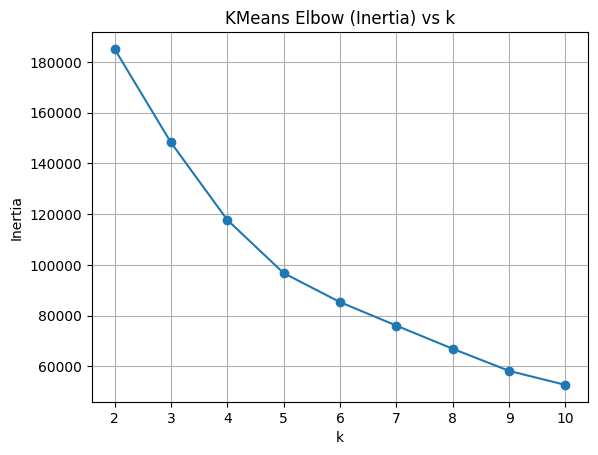

In [ ]:
# elbow plot
plt.figure()
plt.plot(list(ks), inertias, marker="o")
plt.xlabel("k")
plt.ylabel("Inertia")
plt.title("KMeans Elbow (Inertia) vs k")
plt.grid(True)
plt.show()

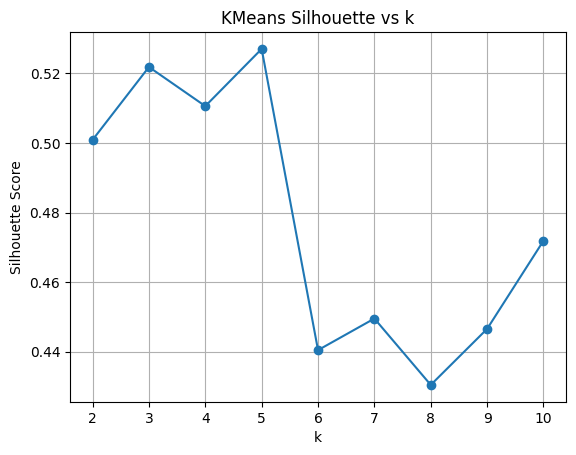

In [ ]:
# silhouette plot
plt.figure()
plt.plot(list(ks), sil_scores, marker="o")
plt.xlabel("k")
plt.ylabel("Silhouette Score")
plt.title("KMeans Silhouette vs k")
plt.grid(True)
plt.show()

### 5.2 KMeans Fit

In [ ]:
k = best_k
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
labels_km = kmeans.fit_predict(X_scaled)

df_customer["cluster_kmeans"] = labels_km

print(f"KMeans k={k}, silhouette={silhouette_score(X_scaled, labels_km):.4f}")
print()
print(df_customer["cluster_kmeans"].value_counts().sort_index())

KMeans k=5, silhouette=0.5270

cluster_kmeans
0    30014
1    11441
2     6606
3     1408
4     3804
Name: count, dtype: int64


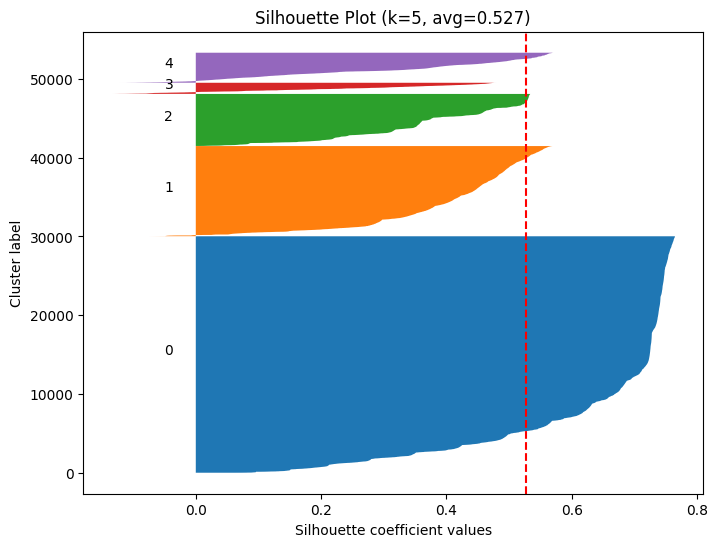

In [ ]:
# silhouette analysis per cluster
sample_sil = silhouette_samples(X_scaled, labels_km)
avg_sil = silhouette_score(X_scaled, labels_km)

plt.figure(figsize=(8, 6))
y_lower = 10
for i in range(k):
    ith = sample_sil[labels_km == i]
    ith.sort()
    size_i = ith.shape[0]
    y_upper = y_lower + size_i
    plt.fill_betweenx(np.arange(y_lower, y_upper), 0, ith)
    plt.text(-0.05, y_lower + 0.5 * size_i, str(i))
    y_lower = y_upper + 10

plt.axvline(avg_sil, linestyle="--", color="red")
plt.xlabel("Silhouette coefficient values")
plt.ylabel("Cluster label")
plt.title(f"Silhouette Plot (k={k}, avg={avg_sil:.3f})")
plt.show()

### 5.3 Cluster Profiling

In [ ]:
# numeric profile per cluster
profile = df_customer.groupby("cluster_kmeans").agg(
    count=("cluster_kmeans", "size"),
    avg_visits=("total_visits", "mean"),
    avg_cost=("avg_cost", "mean"),
    avg_distance=("avg_distance", "mean"),
    loyalty_ratio=("loyalty_ratio", "mean"),
    lt_ord=("loyalty_treatment_ord", "mean"),
    scan_ord=("scan_category_ord", "mean"),
    pct_luxury=("is_luxury", "mean"),
    pct_warranty=("under_warranty", "mean"),
).round(3)

print("Cluster Profiles:")
print(profile.to_string())

Cluster Profiles:
                count  avg_visits  avg_cost  avg_distance  loyalty_ratio  lt_ord  scan_ord  pct_luxury  pct_warranty
cluster_kmeans                                                                                                      
0               30014       3.258   467.560        18.205          0.000   0.000     0.000       0.171         0.718
1               11441       9.094   538.516        18.813          0.253   1.009     0.974       0.180         0.858
2                6606       3.609   452.756        28.284          0.739   2.000     1.357       0.084         0.797
3                1408       2.587  3921.725        49.314          0.029   0.102     0.089       0.479         0.653
4                3804       2.986   716.519       294.934          0.040   0.151     0.123       0.266         0.790


In [ ]:
# dealer distribution per cluster
dealer_dist = pd.crosstab(
    df_customer["cluster_kmeans"],
    df_customer["dealer_name"],
    normalize="index"
).round(3)

print("Dealer distribution by cluster:")
print(dealer_dist.to_string())

Dealer distribution by cluster:
dealer_name     Go Honda  Go Nissan South  Jaguar Land Rover Edmonton  Kentwood Ford  Norden Volkswagen  Porsche Centre Edmonton  Toyota on the Trail
cluster_kmeans                                                                                                                                       
0                  0.195            0.139                       0.095          0.200              0.202                    0.064                0.107
1                  0.241            0.132                       0.115          0.112              0.150                    0.063                0.186
2                  0.221            0.123                       0.055          0.069              0.073                    0.019                0.440
3                  0.063            0.079                       0.308          0.172              0.168                    0.163                0.048
4                  0.142            0.068                       0.19

In [ ]:
# loyalty card breakdown per cluster
loyalty_dist = pd.crosstab(
    df_customer["cluster_kmeans"],
    df_customer["loyalty_binary"],
    normalize="index"
).round(3)
loyalty_dist.columns = ["No Card", "Has Card"]

print("Loyalty card by cluster:")
print(loyalty_dist.to_string())

Loyalty card by cluster:
                No Card  Has Card
cluster_kmeans                   
0                 1.000     0.000
1                 0.694     0.306
2                 0.278     0.722
3                 0.962     0.038
4                 0.956     0.044


### 5.4 Compare Clustering Algorithms

In [ ]:
# Gaussian Mixture Model
gmm = GaussianMixture(n_components=k, random_state=42)
labels_gmm = gmm.fit_predict(X_scaled)

sil_gmm = silhouette_score(X_scaled, labels_gmm)
print(f"GMM silhouette: {sil_gmm:.4f}")
df_customer["cluster_gmm"] = labels_gmm

GMM silhouette: 0.4438


In [ ]:
# Agglomerative Clustering
#agg = AgglomerativeClustering(n_clusters=k)
#labels_agg = agg.fit_predict(X_scaled)

#sil_agg = silhouette_score(X_scaled, labels_agg)
#print(f"Agglomerative silhouette: {sil_agg:.4f}")
#df_customer["cluster_agg"] = labels_agg

In [ ]:
# DBSCAN -- try different eps values
for eps in [0.5, 0.7, 1.0, 1.5]:
    db = DBSCAN(eps=eps, min_samples=20)
    labels_db = db.fit_predict(X_scaled)
    n_clusters = len(set(labels_db)) - (1 if -1 in labels_db else 0)
    n_noise = (labels_db == -1).sum()

    if n_clusters >= 2:
        sil = silhouette_score(X_scaled[labels_db != -1], labels_db[labels_db != -1])
        print(f"DBSCAN eps={eps}: clusters={n_clusters}, noise={n_noise}, silhouette={sil:.3f}")
    else:
        print(f"DBSCAN eps={eps}: clusters={n_clusters}, noise={n_noise}")

DBSCAN eps=0.5: clusters=8, noise=1613, silhouette=0.464
DBSCAN eps=0.7: clusters=7, noise=632, silhouette=0.458
DBSCAN eps=1.0: clusters=4, noise=238, silhouette=0.469
DBSCAN eps=1.5: clusters=3, noise=89, silhouette=0.489


In [ ]:
# summary comparison
print("Clustering Algorithm Comparison:")
print(f"  KMeans (k={k}):        silhouette = {silhouette_score(X_scaled, labels_km):.4f}")
print(f"  GMM (k={k}):           silhouette = {sil_gmm:.4f}")
####print(f"  Agglomerative (k={k}): silhouette = {sil_agg:.4f}")

Clustering Algorithm Comparison:
  KMeans (k=5):        silhouette = 0.5270
  GMM (k=5):           silhouette = 0.4438


### 5.5 Make-Specific Clustering

We repeat the clustering analysis within each of the top vehicle makes to see
if customer segments differ by brand. This is important because a Honda customer
and a Porsche customer may have very different service behaviors even if they
fall into the same overall cluster.

We use the top 7 makes (all have 1,500+ customers). Makes below that threshold
have too few customers for reliable clustering with k=3.

In [ ]:
# map make names back from frequency encoding
df_raw = pd.read_csv('go_auto_cleaned_amended.csv')
vin_make = df_raw.groupby('vin')['make'].first()
df_customer['make_name'] = df_customer['vin'].map(vin_make)

# top 7 makes -- change this number if needed
n_top_makes = 7
top_makes = df_customer['make_name'].value_counts().head(n_top_makes).index

print(f"Top {n_top_makes} makes:")
for make in top_makes:
    count = len(df_customer[df_customer['make_name'] == make])
    print(f"  {make}: {count:,} customers")

Top 7 makes:
  HOND: 10,118 customers
  VW: 8,730 customers
  FORD: 8,602 customers
  TOYO: 7,920 customers
  NISS: 6,526 customers
  LAND: 4,069 customers
  PORS: 3,176 customers


#### 5.5.1 Optimal K Selection per Make

We run the same silhouette analysis from section 5.1 but within each make.
This tells us whether 3 clusters is actually optimal for every brand or
if some makes are better served by 2 or 4 segments.

In [ ]:
make_best_k = {}
make_sil_results = {}

for make_name in top_makes:
    subset = df_customer[df_customer['make_name'] == make_name]
    X_sub = subset[clust_features].fillna(0)
    X_sub_scaled = StandardScaler().fit_transform(X_sub)

    sils = []
    ks = range(2, 8)
    for k_test in ks:
        km = KMeans(n_clusters=k_test, random_state=42, n_init=10)
        labels = km.fit_predict(X_sub_scaled)
        sils.append(silhouette_score(X_sub_scaled, labels))

    best = list(ks)[np.argmax(sils)]
    make_best_k[make_name] = best
    make_sil_results[make_name] = dict(zip(ks, sils))

    print(f"{make_name}: best k={best}, silhouette={max(sils):.3f}")

HOND: best k=5, silhouette=0.526
VW: best k=2, silhouette=0.531
FORD: best k=2, silhouette=0.594
TOYO: best k=7, silhouette=0.469
NISS: best k=5, silhouette=0.553
LAND: best k=2, silhouette=0.475
PORS: best k=5, silhouette=0.586


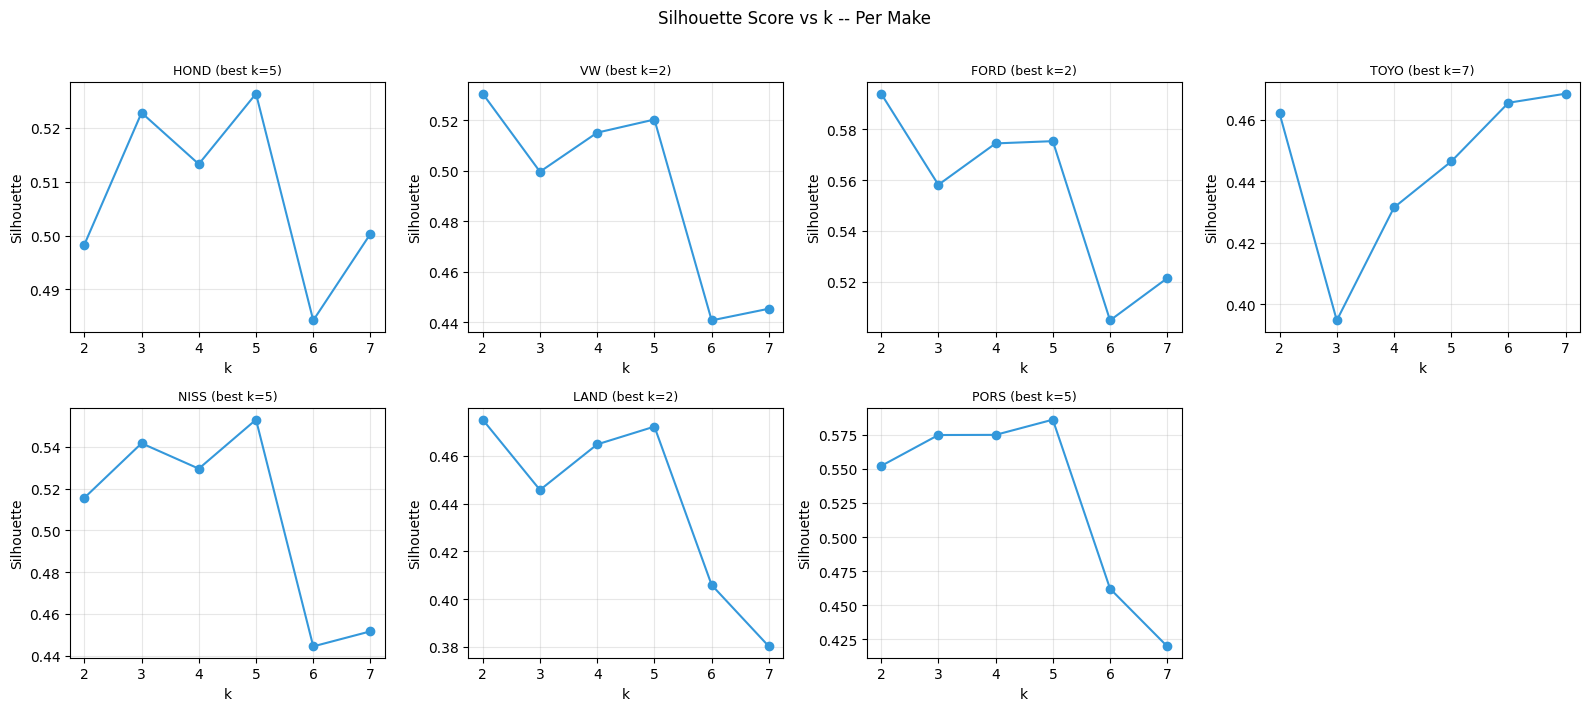

In [ ]:
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
axes = axes.flatten()

for i, make_name in enumerate(top_makes):
    ks = list(make_sil_results[make_name].keys())
    sils = list(make_sil_results[make_name].values())
    best = make_best_k[make_name]

    axes[i].plot(ks, sils, marker='o', color='#3498db')
    axes[i].set_title(f'{make_name} (best k={best})', fontsize=9)
    axes[i].set_xlabel('k')
    axes[i].set_ylabel('Silhouette')
    axes[i].grid(True, alpha=0.3)

# hide unused subplot
if len(top_makes) < len(axes):
    axes[-1].set_visible(False)

fig.suptitle('Silhouette Score vs k -- Per Make', fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

#### 5.5.2 KMeans Fit per Make

Fit KMeans using each make's optimal k and store the cluster labels
for profiling.

In [ ]:
make_cluster_data = {}

for make_name in top_makes:
    subset = df_customer[df_customer['make_name'] == make_name].copy()
    X_sub = subset[clust_features].fillna(0)
    X_sub_scaled = StandardScaler().fit_transform(X_sub)

    best = make_best_k[make_name]
    km = KMeans(n_clusters=best, random_state=42, n_init=10)
    subset['make_cluster'] = km.fit_predict(X_sub_scaled)

    sil = silhouette_score(X_sub_scaled, subset['make_cluster'])
    make_cluster_data[make_name] = subset

    print(f"{make_name}: k={best}, silhouette={sil:.3f}, n={len(subset):,}")
    print(subset['make_cluster'].value_counts().sort_index().to_string())
    print()

HOND: k=5, silhouette=0.526, n=10,118
make_cluster
0    2734
1    5348
2      95
3     525
4    1416

VW: k=2, silhouette=0.531, n=8,730
make_cluster
0    2180
1    6550

FORD: k=2, silhouette=0.594, n=8,602
make_cluster
0    1638
1    6964

TOYO: k=7, silhouette=0.469, n=7,920
make_cluster
0     712
1    1363
2    2720
3      99
4    1720
5     384
6     922

NISS: k=5, silhouette=0.553, n=6,526
make_cluster
0     758
1    3811
2     274
3    1500
4     183

LAND: k=2, silhouette=0.475, n=4,069
make_cluster
0    2747
1    1322

PORS: k=5, silhouette=0.586, n=3,176
make_cluster
0     136
1    2060
2     699
3      31
4     250



#### 5.5.3 Cluster Profiling per Make


Cluster means for key features within each make. This shows whether
the same kinds of segments appear across brands or if some brands
have unique customer patterns.
so there are more ways customers interact with the program. This also explains why
Toyota had the lowest silhouette score-- more diversity in behavior means
more overlap between groups.

In [ ]:
for make_name in top_makes:
    subset = make_cluster_data[make_name]
    profile = subset.groupby('make_cluster').agg(
        count=('make_cluster', 'size'),
        avg_visits=('total_visits', 'mean'),
        avg_cost=('avg_cost', 'mean'),
        avg_distance=('avg_distance', 'mean'),
        loyalty_ratio=('loyalty_ratio', 'mean')
    ).round(2)

    print(f"--- {make_name} ---")
    print(profile.to_string())
    print()

--- HOND ---
              count  avg_visits  avg_cost  avg_distance  loyalty_ratio
make_cluster                                                          
0              2734        9.23    401.34         16.93           0.27
1              5348        3.02    354.89         18.60           0.00
2                95        1.62   4020.90         56.32           0.08
3               525        3.23    474.79        306.55           0.07
4              1416        3.70    423.53         29.17           0.72

--- VW ---
              count  avg_visits  avg_cost  avg_distance  loyalty_ratio
make_cluster                                                          
0              2180        7.47    611.09         37.96           0.33
1              6550        3.66    630.31         50.68           0.00

--- FORD ---
              count  avg_visits  avg_cost  avg_distance  loyalty_ratio
make_cluster                                                          
0              1638        7.99    489

After fitting KMeans on each make, we profiled the resulting clusters by looking
at the mean values of key features (visits, cost, distance, loyalty ratio) per cluster.
From this we noticed the same customer archetypes showing up across different makes:

- **Non-Loyalty Majority** -- zero or near-zero loyalty ratio, low visit count, biggest group in every make
- **Loyal Core** -- loyalty ratio above 0.6, moderate visits and cost
- **Power Users** -- high visit frequency (8+ visits), moderate loyalty
- **Distance Travelers** -- average distance 270+ km, typically low loyalty
- **Major Repairs** -- very high avg cost ($3K+), only 1-2 visits

Not every make has all five types. VW, Ford, and Land Rover only split into 2 clusters
(engaged vs non-engaged), which means their customer base is more behaviorally uniform.
Toyota has the most segments (7 clusters) because it has the highest loyalty adoption
so there are more ways customers interact with the program. This also explains why
Toyota had the lowest silhouette score (0.395) -- more diversity in behavior means
more overlap between groups.

In [ ]:
for make_name in top_makes:
    subset = make_cluster_data[make_name]
    loyalty_dist = pd.crosstab(
        subset['make_cluster'],
        subset['loyalty_binary'],
        normalize='index'
    ).round(3)
    loyalty_dist.columns = ['No Card', 'Has Card']

    print(f"--- {make_name} loyalty breakdown ---")
    print(loyalty_dist.to_string())
    print()

--- HOND loyalty breakdown ---
              No Card  Has Card
make_cluster                   
0               0.730     0.270
1               1.000     0.000
2               0.916     0.084
3               0.945     0.055
4               0.378     0.622

--- VW loyalty breakdown ---
              No Card  Has Card
make_cluster                   
0               0.555     0.445
1               1.000     0.000

--- FORD loyalty breakdown ---
              No Card  Has Card
make_cluster                   
0               0.585     0.415
1               1.000     0.000

--- TOYO loyalty breakdown ---
              No Card  Has Card
make_cluster                   
0               0.656     0.344
1               0.644     0.356
2               1.000     0.000
3               0.869     0.131
4               0.333     0.667
5               0.789     0.211
6               0.000     1.000

--- NISS loyalty breakdown ---
              No Card  Has Card
make_cluster                   
0          

#### 5.5.4 Algorithm Comparison per Make

Compare KMeans vs GMM across all makes. This checks whether the clusters
are better captured by hard (KMeans) or soft (GMM) assignment.

In [ ]:
print(f"{'Make':<6s}  {'KMeans':>8s}  {'GMM':>8s}  {'Winner':>8s}")
print("-" * 36)

for make_name in top_makes:
    subset = df_customer[df_customer['make_name'] == make_name]
    X_sub = subset[clust_features].fillna(0)
    X_sub_scaled = StandardScaler().fit_transform(X_sub)
    best = make_best_k[make_name]

    km = KMeans(n_clusters=best, random_state=42, n_init=10)
    km_labels = km.fit_predict(X_sub_scaled)
    km_sil = silhouette_score(X_sub_scaled, km_labels)

    gmm = GaussianMixture(n_components=best, random_state=42)
    gmm_labels = gmm.fit_predict(X_sub_scaled)
    gmm_sil = silhouette_score(X_sub_scaled, gmm_labels)

    winner = 'KMeans' if km_sil >= gmm_sil else 'GMM'
    print(f"{make_name:<6s}  {km_sil:>8.3f}  {gmm_sil:>8.3f}  {winner:>8s}")

Make      KMeans       GMM    Winner
------------------------------------
HOND       0.526     0.480    KMeans
VW         0.531     0.531    KMeans
FORD       0.594     0.594    KMeans
TOYO       0.469     0.417    KMeans
NISS       0.553     0.517    KMeans
LAND       0.475     0.273    KMeans
PORS       0.586     0.485    KMeans


#### 5.5.5 Make-Specific Visualizations

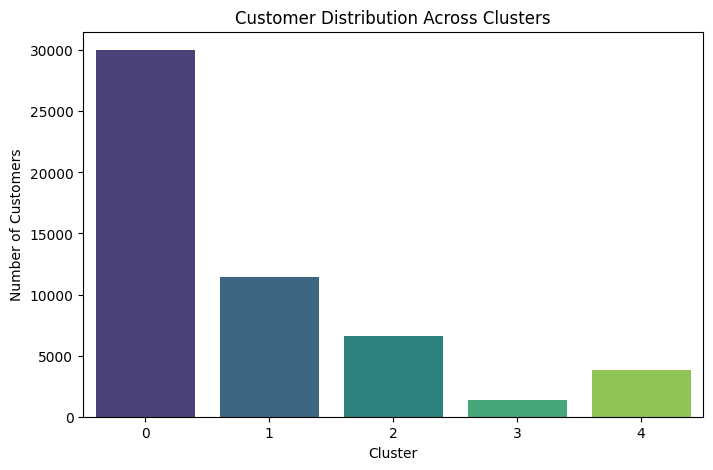

In [ ]:
## 1. CLUSTER SIZE DISTRIBUTION
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.countplot(x='cluster_kmeans', data=df_customer, palette='viridis')

plt.title("Customer Distribution Across Clusters")
plt.xlabel("Cluster")
plt.ylabel("Number of Customers")

plt.show()

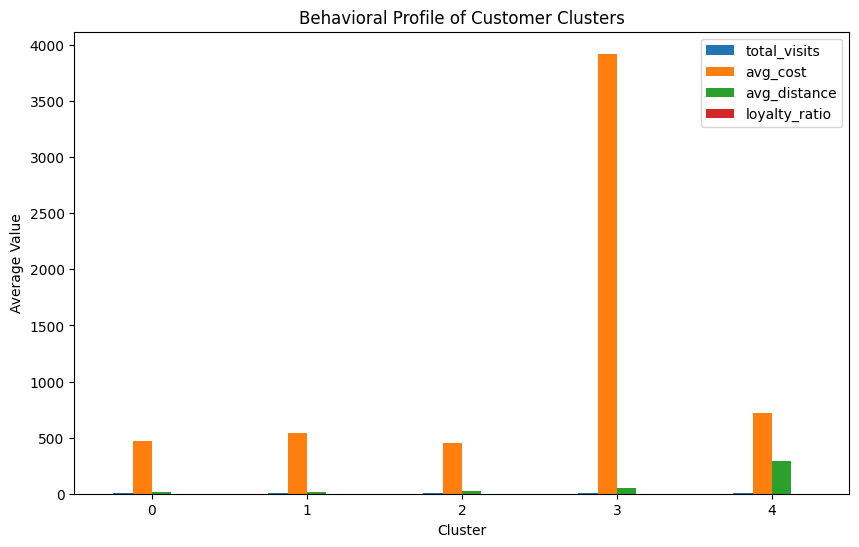

In [ ]:
## 2. CLUSTER BEHAVIORAL PROFILE
cluster_profile = df_customer.groupby("cluster_kmeans")[[
    "total_visits",
    "avg_cost",
    "avg_distance",
    "loyalty_ratio"
]].mean()

cluster_profile.plot(kind="bar", figsize=(10,6))

plt.title("Behavioral Profile of Customer Clusters")
plt.ylabel("Average Value")
plt.xlabel("Cluster")

plt.xticks(rotation=0)
plt.show()

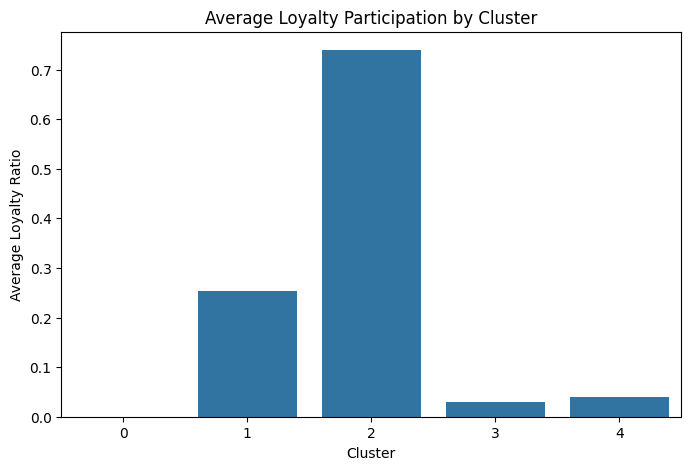

In [ ]:
## 3. LOYALTY ENGAGEMENT BY CLUSTER
plt.figure(figsize=(8,5))

sns.barplot(
    x="cluster_kmeans",
    y="loyalty_ratio",
    data=df_customer,
    ci=None
)

plt.title("Average Loyalty Participation by Cluster")
plt.xlabel("Cluster")
plt.ylabel("Average Loyalty Ratio")

plt.show()

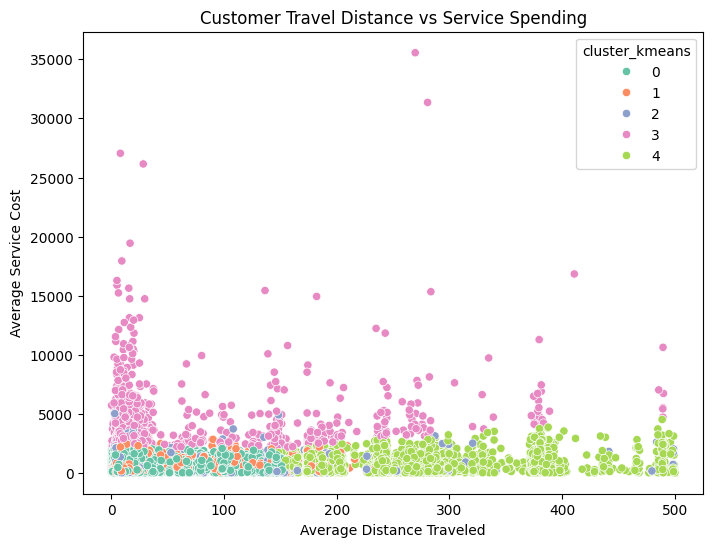

In [ ]:
## 4. DISTANCE vs SPENDING
plt.figure(figsize=(8,6))

sns.scatterplot(
    x="avg_distance",
    y="avg_cost",
    hue="cluster_kmeans",
    data=df_customer,
    palette="Set2"
)

plt.title("Customer Travel Distance vs Service Spending")
plt.xlabel("Average Distance Traveled")
plt.ylabel("Average Service Cost")

plt.show()

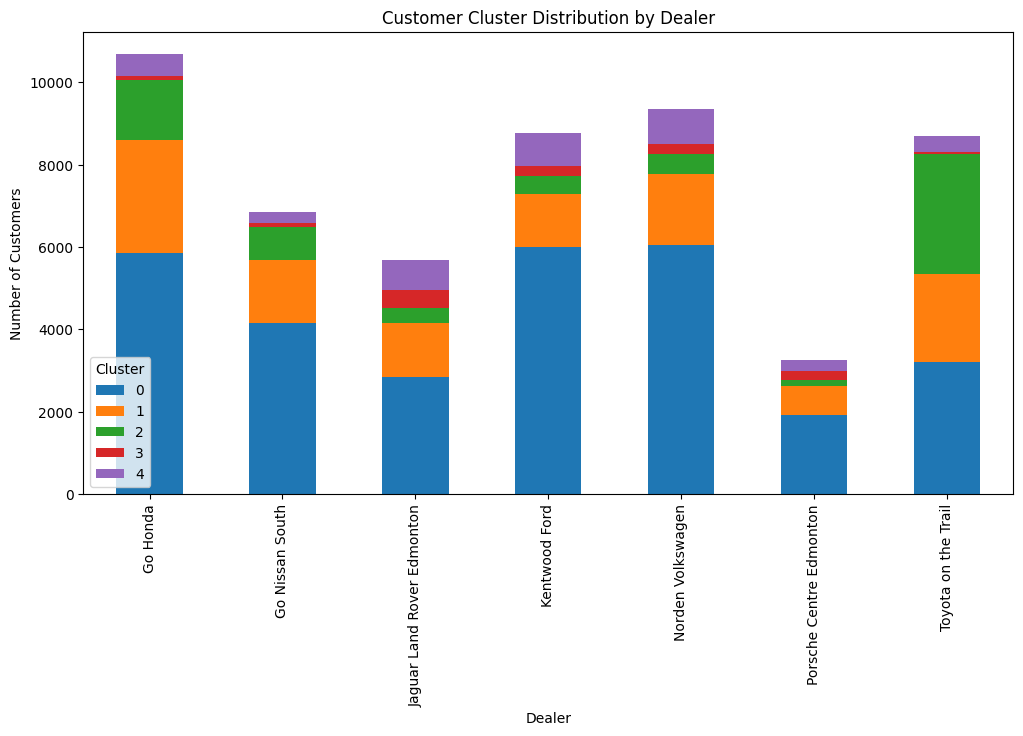

In [ ]:
## 5. DISTANCE DISTRIBUTION ACROSS CLUSTERS
dealer_cluster = pd.crosstab(
    df_customer["dealer_name"],
    df_customer["cluster_kmeans"]
)

dealer_cluster.plot(
    kind="bar",
    stacked=True,
    figsize=(12,6)
)

plt.title("Customer Cluster Distribution by Dealer")
plt.xlabel("Dealer")
plt.ylabel("Number of Customers")

plt.legend(title="Cluster")

plt.show()

## 6. Dealer Performance

### 6.1 Dealer Aggregation

In [ ]:
dealer_perf = df_customer.groupby("dealer_name").agg(
    total_customers=("vin", "count"),
    avg_cost=("avg_cost", "mean"),
    avg_distance=("avg_distance", "mean"),
    avg_visits=("total_visits", "mean"),
    loyalty_rate=("loyalty_ratio", "mean")
).sort_values("loyalty_rate", ascending=False)

print(dealer_perf.round(2))

                            total_customers  avg_cost  avg_distance  \
dealer_name                                                           
Toyota on the Trail                    8691    344.89         31.07   
Go Honda                              10691    414.51         34.87   
Go Nissan South                        6850    444.00         23.46   
Jaguar Land Rover Edmonton             5685   1153.50         68.12   
Norden Volkswagen                      9340    626.66         46.91   
Porsche Centre Edmonton                3241   1198.10         44.76   
Kentwood Ford                          8775    532.05         41.70   

                            avg_visits  loyalty_rate  
dealer_name                                           
Toyota on the Trail               4.60          0.34  
Go Honda                          4.63          0.17  
Go Nissan South                   4.22          0.14  
Jaguar Land Rover Edmonton        4.58          0.11  
Norden Volkswagen             

### 6.2 Dealer Clustering

In [ ]:
dealer_features = dealer_perf[
    ["avg_cost", "avg_distance", "avg_visits", "loyalty_rate"]
]

scaler_dealer = StandardScaler()
X_dealer = scaler_dealer.fit_transform(dealer_features)

kmeans_dealer = KMeans(n_clusters=3, random_state=42)
dealer_perf["dealer_cluster"] = kmeans_dealer.fit_predict(X_dealer)

print(dealer_perf)

                            total_customers     avg_cost  avg_distance  \
dealer_name                                                              
Toyota on the Trail                    8691   344.887299     31.072802   
Go Honda                              10691   414.509872     34.867202   
Go Nissan South                        6850   444.002484     23.459355   
Jaguar Land Rover Edmonton             5685  1153.495043     68.120396   
Norden Volkswagen                      9340   626.662749     46.907224   
Porsche Centre Edmonton                3241  1198.103852     44.756076   
Kentwood Ford                          8775   532.051810     41.696990   

                            avg_visits  loyalty_rate  dealer_cluster  
dealer_name                                                           
Toyota on the Trail           4.596939      0.339418               2  
Go Honda                      4.634365      0.172499               0  
Go Nissan South               4.219416      0.144

### 6.3 Dealer Comparison Visualization

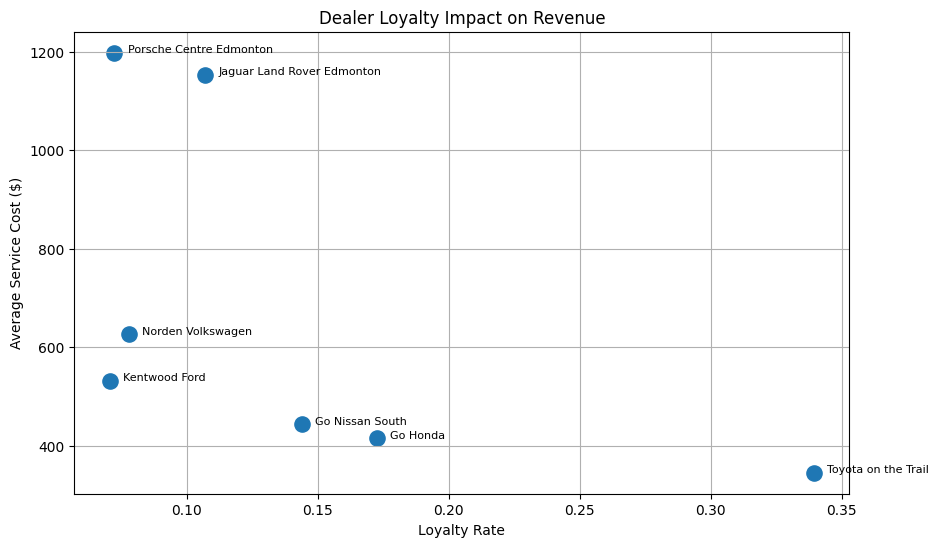

In [ ]:
plt.figure(figsize=(10, 6))
plt.scatter(
    dealer_perf["loyalty_rate"],
    dealer_perf["avg_cost"],
    s=120
)

for dealer in dealer_perf.index:
    plt.text(
        dealer_perf.loc[dealer, "loyalty_rate"] + 0.005,
        dealer_perf.loc[dealer, "avg_cost"],
        dealer, fontsize=8
    )

plt.xlabel("Loyalty Rate")
plt.ylabel("Average Service Cost ($)")
plt.title("Dealer Loyalty Impact on Revenue")
plt.grid(True)
plt.show()

### 6.4 Dealer Location Map

In [ ]:
import folium

# real dealership coordinates (from Google Places)
dealer_coords = {
    'Go Honda':                     (53.5443, -113.6414),
    'Norden Volkswagen':            (53.5988, -113.5760),
    'Toyota on the Trail':          (53.4895, -113.4963),
    'Kentwood Ford':                (53.5941, -113.4931),
    'Go Nissan South':              (53.4213, -113.4906),
    'Jaguar Land Rover Edmonton':   (53.5587, -113.6163),
    'Porsche Centre Edmonton':      (53.5404, -113.6361)
}

# colour dealers by loyalty rate
def loyalty_colour(rate):
    if rate > 0.25:
        return 'green'
    elif rate > 0.15:
        return 'orange'
    else:
        return 'red'

# add lat/lon to dealer_perf
dealer_perf['latitude'] = dealer_perf.index.map(lambda x: dealer_coords[x][0])
dealer_perf['longitude'] = dealer_perf.index.map(lambda x: dealer_coords[x][1])

# centre map around Edmonton dealerships
edmonton_center = [
    dealer_perf['latitude'].mean(),
    dealer_perf['longitude'].mean()
]

m = folium.Map(location=edmonton_center, zoom_start=11, tiles='cartodbpositron')

# add dealer markers
for _, row in dealer_perf.iterrows():
    name = row.name
    if name not in dealer_coords:
        continue
    lat, lon = dealer_coords[name]
    colour = loyalty_colour(row['loyalty_rate'])
    radius = max(6, row['total_customers'] / 500)

    popup_text = (
        f"<b>{name}</b><br>"
        f"Customers: {row['total_customers']:,}<br>"
        f"Loyalty Rate: {row['loyalty_rate']*100:.1f}%<br>"
        f"Avg Cost: ${row['avg_cost']:.0f}<br>"
        f"Avg Visits: {row['avg_visits']:.1f}"
    )

    folium.CircleMarker(
        location=[lat, lon],
        radius=radius,
        color=colour,
        fill=True,
        fill_color=colour,
        fill_opacity=0.7,
        popup=folium.Popup(popup_text, max_width=250),
        tooltip=name
    ).add_to(m)

m

## 7. Client Recommendations -- Visualizations



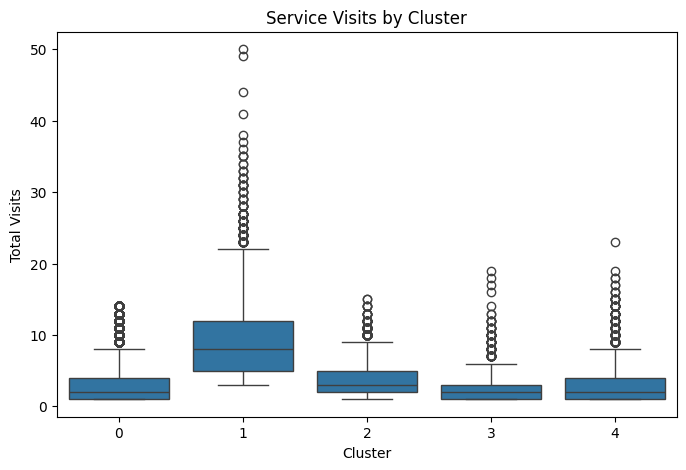

In [ ]:
## RECOMMENDATION-1 : Strengthen Loyalty Engagement
plt.figure(figsize=(8,5))

sns.boxplot(
    x="cluster_kmeans",
    y="total_visits",
    data=df_customer
)

plt.title("Service Visits by Cluster")
plt.xlabel("Cluster")
plt.ylabel("Total Visits")

plt.show()

- The above visualization compares the distribution of service visit frequency across the identified customer clusters. The clusters represent groups of customers with different service behaviors and loyalty engagement patterns.

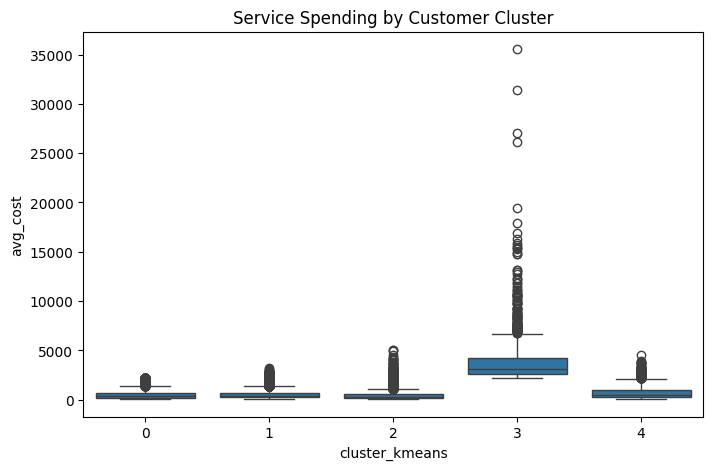

In [ ]:
## RECOMMENDATION-2 : Target High-Value Customer Segments
plt.figure(figsize=(8,5))

sns.boxplot(
    x="cluster_kmeans",
    y="avg_cost",
    data=df_customer
)

plt.title("Service Spending by Customer Cluster")

plt.show()

- This chart illustrates how average service spending varies across the customer clusters. It helps identify which customer segments contribute higher revenue through service activities.

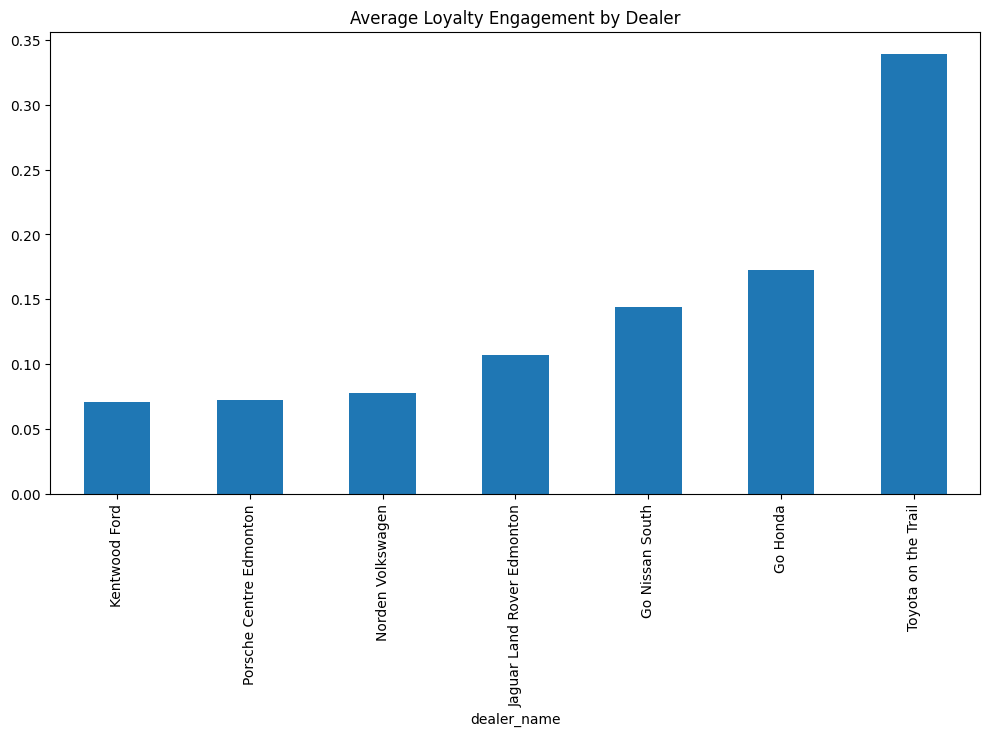

In [ ]:
## RECOMMENDATION-3 : Optimize Dealer Performance
dealer_loyalty = df_customer.groupby("dealer_name")["loyalty_ratio"].mean()

dealer_loyalty.sort_values().plot(
    kind="bar",
    figsize=(12,6)
)

plt.title("Average Loyalty Engagement by Dealer")

plt.show()

- The visualization above shows the average loyalty participation rate across different dealerships. It highlights differences in how effectively dealerships engage customers in the loyalty program.

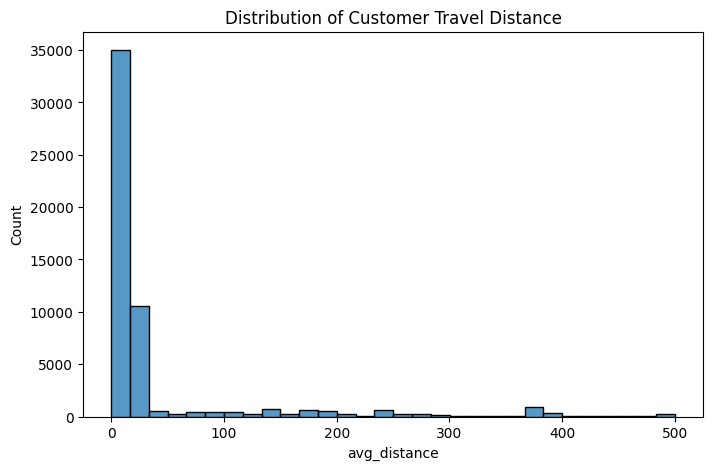

In [ ]:
## RECOMMENDATION-4 : Geographic Targeting
plt.figure(figsize=(8,5))

sns.histplot(
    df_customer["avg_distance"],
    bins=30
)

plt.title("Distribution of Customer Travel Distance")

plt.show()

- This distribution displays how far customers typically travel to reach service locations. It provides insights into customer proximity to dealerships and potential geographic service gaps.

## 8. Business Insights and Strategic Implications

This analysis applied customer-level clustering to understand service behavior, spending patterns, loyalty engagement, and geographic factors across the Go Auto dealership network. By aggregating service records at the vehicle level and applying unsupervised machine learning techniques, the analysis identified distinct customer segments that differ in their interaction with the dealership network.

The clustering results reveal clear differences in service frequency and spending patterns among customers. Some segments exhibit low service engagement and infrequent visits, while other clusters represent highly engaged customers who service their vehicles more frequently and contribute significantly to overall service revenue. These behavioral differences highlight the importance of segment-specific engagement strategies rather than treating all customers uniformly.

-Loyalty program participation also shows meaningful variation across clusters. Customers who demonstrate stronger loyalty engagement tend to maintain more consistent service relationships with the dealership network. This suggests that expanding loyalty program adoption could play a key role in increasing customer retention, encouraging repeat service visits, and strengthening long-term customer relationships.

-Dealer-level analysis further indicates differences in loyalty engagement across dealership locations. Some dealers achieve stronger customer engagement and retention than others, suggesting opportunities to share best practices, improve operational processes, and strengthen customer experience at underperforming locations.

-Geographic analysis of customer travel distances provides additional insight into service accessibility and customer behavior. While many customers service their vehicles close to their location, some travel longer distances, potentially indicating strong brand trust or limited service availability in certain areas. These patterns can inform regional marketing strategies and future dealership planning decisions.

Overall, the clustering-based segmentation provides Go Auto with a data-driven understanding of customer service behavior across its network. By leveraging these insights, the organization can design targeted marketing initiatives, strengthen loyalty engagement, optimize dealership performance, and ultimately improve customer retention and long-term service revenue.